In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import re
import glob
import traceback
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import Client, LocalCluster
from dask.distributed import as_completed as dask_as_completed
import numpy as np
from scipy.interpolate import RBFInterpolator
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
import scipy
from scipy.interpolate import RBFInterpolator
import matplotlib.colors as mcolors

In [2]:
def get_allocated_cpus():
    if "SLURM_CPUS_PER_TASK" in os.environ:
        return int(os.environ["SLURM_CPUS_PER_TASK"])
    if "SLURM_CPUS_ON_NODE" in os.environ:
        return int(os.environ["SLURM_CPUS_ON_NODE"])
    try:
        return len(os.sched_getaffinity(0))
    except AttributeError:
        return os.cpu_count()


def get_allocated_memory_gb():
    """
    Best-effort read of the SLURM memory allocation, since dask.distributed
    needs an explicit per-worker memory_limit to manage spilling correctly.
    Falls back to None if it can't be determined -- in that case you MUST
    set SLURM_MEM_GB yourself (see bottom of file) or dask will guess from
    the whole node's memory, which is wrong on a shared node.
    """
    mem_str = os.environ.get("SLURM_MEM_PER_NODE") or os.environ.get("SLURM_MEM_PER_CPU")
    if mem_str is None:
        return None
    mem_mb = int(mem_str)
    if "SLURM_MEM_PER_CPU" in os.environ and "SLURM_MEM_PER_NODE" not in os.environ:
        mem_mb *= get_allocated_cpus()
    return mem_mb / 1024


def process_single_case(nc_path):
    """
    Processes one case out-of-core via dask-backed
    xarray, computes q_tot, and never materializes the full variable.
    Returns a dict with either results or an "error" key -- never raises,
    so a single bad file doesn't take down the whole batch.
    """
    folder_name = os.path.basename(os.path.dirname(nc_path))
    match = re.search(r"run_hm0_([\d\.]+)_s0_([\d\.]+)_ang_([\d\.-]+)", folder_name)

    if not match:
        return {"folder": folder_name, "error": "folder name did not match expected pattern"}

    hm0_val = float(match.group(1))
    s0_val = float(match.group(2))
    ang_val = float(match.group(3))
    tp_val = np.sqrt(hm0_val / (1.56 * s0_val))

    try:
        with xr.open_dataset(nc_path, chunks={"globaltime": 20}) as ds:
            total_sed = ds["Svsg"] + ds["Svbg"]

            time_avg = total_sed.mean(dim="globaltime")
            y_mask = ((ds["globaly"] >= 800) & (ds["globaly"] <= 1200)).compute()
            transport_y_filtered = time_avg.where(y_mask, drop=True)
            # Pick 20 evenly-spaced indices across the filtered ny range
            n_profiles = transport_y_filtered.sizes["ny"]
            idx = np.linspace(0, n_profiles - 1, 20).round().astype(int)
            idx = np.unique(idx)  # avoids duplicate indices if n_profiles < 20
            transport_y_subset = transport_y_filtered.isel(ny=idx)
            profile_1d = transport_y_subset.mean(dim="ny")

            x_coord_1d = (ds["globalx"].compute().where(y_mask, drop=True).isel(ny=idx).mean(dim="ny"))
            profile_1d = profile_1d.assign_coords(x_coord=("nx", x_coord_1d.data))
            integrated = profile_1d.integrate(coord="x_coord").compute()
            q_tot_val = integrated.squeeze().item()

            return {
                "hm0": hm0_val,
                "s0": s0_val,
                "tp": tp_val,
                "mainang": ang_val,
                "q_tot": q_tot_val,
                "folder": folder_name,
            }

    except Exception as e:
        return {
            "folder": folder_name,
            "path": nc_path,
            "error": f"{type(e).__name__}: {e}",
            "trace": traceback.format_exc(),
        }

In [3]:
if __name__ == "__main__":
    run_dir = "xbeach_cases"
    nc_files = sorted(glob.glob(os.path.join(run_dir, "run_hm0_*_s0_*_ang_*", "xboutput.nc")))
    print(f"Found {len(nc_files)} output files to process.")

    if not nc_files:
        raise SystemExit("No files found -- check run_dir/glob pattern before proceeding.")

    allocated_cpus = get_allocated_cpus()
    allocated_mem_gb = get_allocated_memory_gb()

    if allocated_mem_gb is None:
        allocated_mem_gb = float(os.environ.get("SLURM_MEM_GB", 0)) or None

    if allocated_mem_gb is None:
        raise SystemExit(
            "Could not determine allocated memory from SLURM env vars. "
            "Set SLURM_MEM_GB=<your job's total memory in GB> before running, "
            "e.g. os.environ['SLURM_MEM_GB'] = '128' at the top of this script."
        )

    NUM_WORKERS = int(os.environ.get("NUM_WORKERS_OVERRIDE", min(8, allocated_cpus)))
    mem_per_worker_gb = max(1, int(allocated_mem_gb / NUM_WORKERS * 0.85))  # 15% headroom

    print(f"Allocated: {allocated_cpus} CPUs, {allocated_mem_gb:.0f} GB RAM")
    print(f"Using {NUM_WORKERS} dask workers, {mem_per_worker_gb} GB memory_limit each")

    cluster = LocalCluster(
        n_workers=NUM_WORKERS,
        threads_per_worker=1,
        memory_limit=f"{mem_per_worker_gb}GB",
        processes=True,
        host="127.0.0.1",
    )
    client = Client(cluster)
    print(f"Dask dashboard: {client.dashboard_link}")
    print("(if running on a remote cluster, you'll need to port-forward this URL to view it)")

    # --- Smoke test: process one file before committing the full batch ---
    print("Running smoke test on first file (this may take a while given file size)...")
    smoke_future = client.submit(process_single_case, nc_files[0])
    smoke_result = smoke_future.result()
    if smoke_result.get("error"):
        client.close()
        cluster.close()
        raise RuntimeError(
            f"Smoke test failed on {smoke_result['folder']}: {smoke_result['error']}\n"
            f"{smoke_result.get('trace', '')}"
        )
    print(f"Smoke test OK ({smoke_result['folder']}). Launching full batch...")

    futures = client.map(process_single_case, nc_files)

    results = []
    errors = []
    completed_count = 0
    for future in dask_as_completed(futures):
        completed_count += 1
        try:
            res = future.result()
        except Exception as e:
            errors.append({"error": f"{type(e).__name__}: {e}"})
            print(f"[{completed_count}/{len(nc_files)}] ✗ worker/task crashed: {e}")
            continue

        if res.get("error"):
            errors.append(res)
            print(f"[{completed_count}/{len(nc_files)}] ✗ {res['folder']}: {res['error']}")
        else:
            results.append(res)
            print(f"[{completed_count}/{len(nc_files)}] ✓ {res['folder']}")

    client.close()
    cluster.close()

    df_results = pd.DataFrame(results)
    df_results.to_csv("q_tot_summary_3d.csv", index=False)
    print(f"\nSuccessfully processed {len(df_results)} / {len(nc_files)} cases.")

    if errors:
        df_errors = pd.DataFrame(errors)
        df_errors.to_csv("q_tot_errors_3d.csv", index=False)
        print(f"{len(errors)} cases failed -- see q_tot_errors.csv for details.")

Found 200 output files to process.
Allocated: 40 CPUs, 208 GB RAM
Using 8 dask workers, 22 GB memory_limit each
Dask dashboard: http://127.0.0.1:8787/status
(if running on a remote cluster, you'll need to port-forward this URL to view it)
Running smoke test on first file (this may take a while given file size)...
Smoke test OK (run_hm0_0.50_s0_0.0175_ang_297.24). Launching full batch...
[1/200] ✓ run_hm0_0.55_s0_0.0148_ang_258.19
[2/200] ✓ run_hm0_0.53_s0_0.0225_ang_200.88
[3/200] ✓ run_hm0_0.63_s0_0.0202_ang_322.31
[4/200] ✓ run_hm0_0.61_s0_0.0268_ang_246.46
[5/200] ✓ run_hm0_0.51_s0_0.0229_ang_239.13
[6/200] ✓ run_hm0_0.55_s0_0.0258_ang_313.46
[7/200] ✓ run_hm0_0.53_s0_0.0226_ang_227.89
[8/200] ✓ run_hm0_0.63_s0_0.0177_ang_309.33
[9/200] ✓ run_hm0_0.57_s0_0.0222_ang_319.59
[10/200] ✓ run_hm0_0.62_s0_0.0129_ang_311.75
[11/200] ✓ run_hm0_0.54_s0_0.0177_ang_267.43
[12/200] ✓ run_hm0_0.52_s0_0.0215_ang_222.53
[13/200] ✓ run_hm0_0.52_s0_0.0153_ang_291.29
[14/200] ✓ run_hm0_0.54_s0_0.0167_

**START HERE IF YOU DONT NEED POSTPROCESSING**

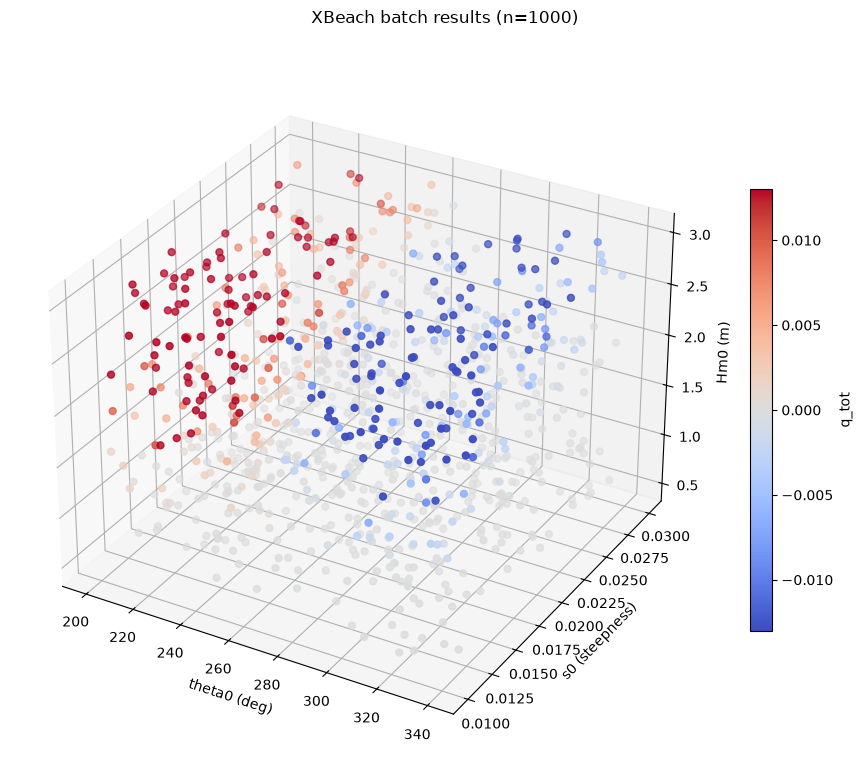

In [3]:
df_results = pd.read_csv("q_tot_summary_dx5.csv")

vmax = np.max(np.abs(df_results["q_tot"]))
norm = plt.Normalize(-vmax/10, vmax/10)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    df_results["mainang"], df_results["s0"], df_results["hm0"],
    c=df_results["q_tot"], cmap="coolwarm", norm=norm, s=25,
)
ax.set_xlabel("theta0 (deg)")
ax.set_ylabel("s0 (steepness)")
ax.set_zlabel("Hm0 (m)")
ax.grid(True, linestyle=":", alpha=0.5)
fig.colorbar(sc, ax=ax, shrink=0.6, label="q_tot")
plt.suptitle(f"XBeach batch results (n={len(df_results)})")
plt.tight_layout()
plt.show()

In [4]:
points = df_results[["mainang", "s0", "hm0"]].to_numpy()
values = df_results["q_tot"].to_numpy()

p_mean = points.mean(axis=0)
p_std  = points.std(axis=0)
p_std[p_std == 0] = 1.0

rbf = RBFInterpolator((points - p_mean) / p_std, values, kernel="cubic")

def predict(ang, s0, hm0):
    """ang, s0, hm0: broadcastable arrays. Returns q_tot with their shape."""
    ang, s0, hm0 = np.broadcast_arrays(ang, s0, hm0)
    q = np.column_stack([ang.ravel(), s0.ravel(), hm0.ravel()])
    return rbf((q - p_mean) / p_std).reshape(ang.shape)

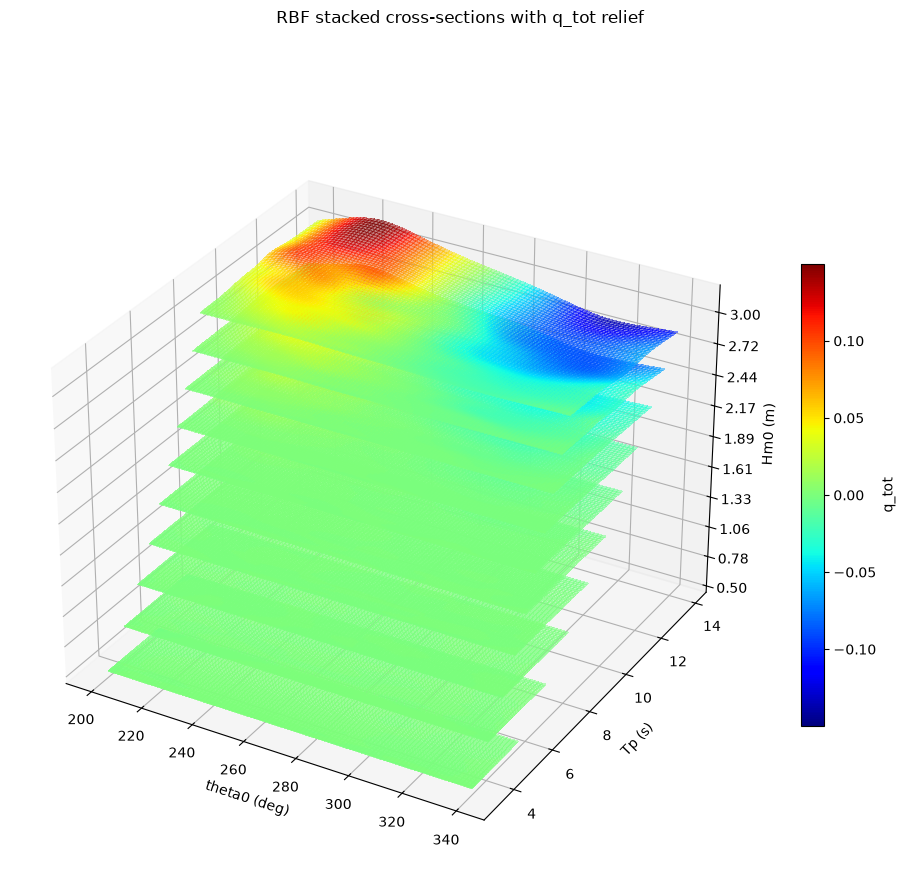

In [5]:
n = 100 # grid reslution
hm0_slices = np.linspace(df_results["hm0"].min(), df_results["hm0"].max(), 10)

ang_lin = np.linspace(df_results["mainang"].min(), df_results["mainang"].max(), n)
s0_lin  = np.linspace(df_results["s0"].min(), df_results["s0"].max(), n)
ang_grid, s0_grid = np.meshgrid(ang_lin, s0_lin)

q_slices = [predict(ang_grid, s0_grid, h) for h in hm0_slices]

vmax = np.nanmax(np.abs(np.stack(q_slices)))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)   # diverging: sign matters
cmap = plt.get_cmap("jet")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

stack_spacing = 3.0 * vmax
exaggeration  = 2.0

g = scipy.constants.g

for i, (hm0, q) in enumerate(zip(hm0_slices, q_slices)):
    tp_grid = np.sqrt(2 * np.pi * hm0 / (g * s0_grid))   
    z_offset  = i * stack_spacing
    z_surface = z_offset + exaggeration * q
    ax.plot_surface(
        ang_grid, tp_grid, z_surface,          
        facecolors=cmap(norm(q)),
        rstride=1, cstride=1,
        shade=False, antialiased=False,
        linewidth=0, alpha=0.5,
    )

ax.set_xlabel("theta0 (deg)")
ax.set_ylabel("Tp (s)")
ax.set_zlabel("Hm0 (m)")
ax.set_zticks([i * stack_spacing for i in range(len(hm0_slices))])
ax.set_zticklabels([f"{hm0:.2f}" for hm0 in hm0_slices])

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, label="q_tot")
plt.suptitle("RBF stacked cross-sections with q_tot relief")
plt.show()

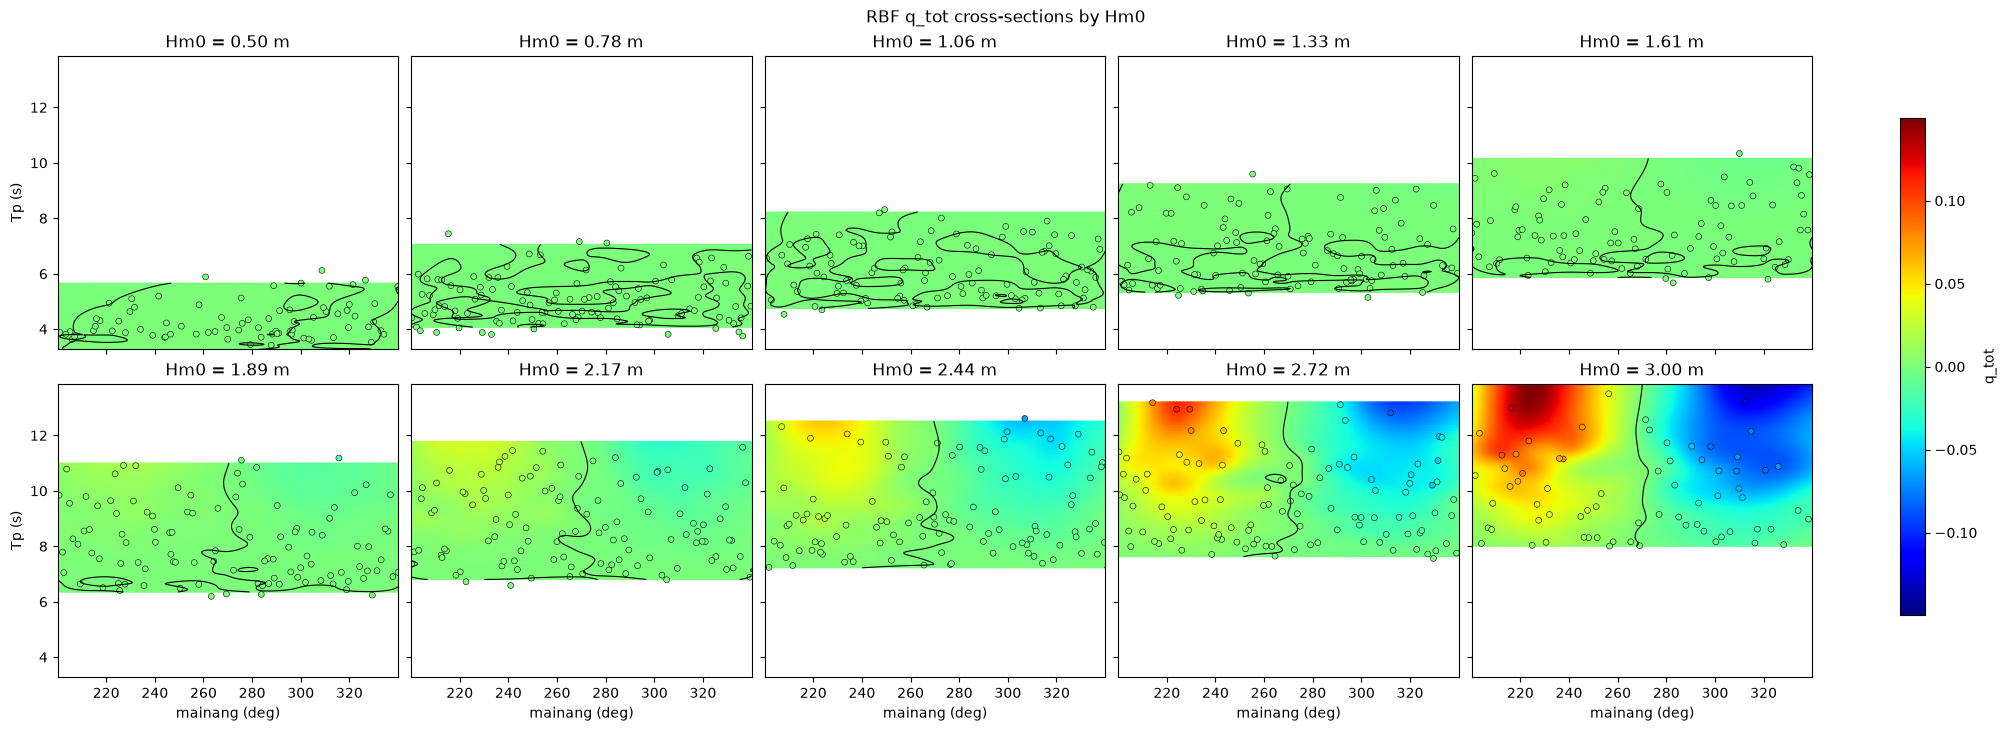

In [6]:
n = 100              # grid resolution
shared_scale = True  # False = each panel gets its own colour scale (shows small-wave patterns)
show_data = True     # overlay XBeach cases near each Hm0 slice

g = scipy.constants.g
hm0_slices = np.linspace(df_results["hm0"].min(), df_results["hm0"].max(), 10)
ang_lin = np.linspace(df_results["mainang"].min(), df_results["mainang"].max(), n)
s0_lin  = np.linspace(df_results["s0"].min(), df_results["s0"].max(), n)
ang_grid, s0_grid = np.meshgrid(ang_lin, s0_lin)

q_slices = [predict(ang_grid, s0_grid, h) for h in hm0_slices]
vmax = np.nanmax(np.abs(np.stack(q_slices)))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)   # diverging: sign matters
cmap = plt.get_cmap("jet")
half_band = (hm0_slices[1] - hm0_slices[0]) / 2

fig, axes = plt.subplots(2, 5, figsize=(20, 7.2), sharex=True, sharey=True, constrained_layout=True)

for ax, hm0, q in zip(axes.flat, hm0_slices, q_slices):
    if not shared_scale:
        v = np.nanmax(np.abs(q)) or 1.0
        norm = mcolors.TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    tp_grid = np.sqrt(2 * np.pi * hm0 / (g * s0_grid))
    ax.pcolormesh(ang_grid, tp_grid, q, cmap=cmap, norm=norm, shading="gouraud")
    if np.nanmin(q) < 0 < np.nanmax(q):
        ax.contour(ang_grid, tp_grid, q, levels=[0], colors="k", linewidths=0.8)   # direction change
    if show_data:
        near = (df_results["hm0"] - hm0).abs() <= half_band
        ax.scatter(df_results.loc[near, "mainang"], df_results.loc[near, "tp"],
                   c=df_results.loc[near, "q_tot"], cmap=cmap, norm=norm,
                   s=18, edgecolors="k", linewidths=0.4)
    ax.set_title(f"Hm0 = {hm0:.2f} m")
    if not shared_scale:
        fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.9, format="%.1e")

for ax in axes[-1]:
    ax.set_xlabel("mainang (deg)")
for ax in axes[:, 0]:
    ax.set_ylabel("Tp (s)")

if shared_scale:
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.8, label="q_tot")
fig.suptitle("RBF q_tot cross-sections by Hm0" + ("" if shared_scale else " (each panel on its own colour scale)"))
plt.show()

**Use this to weird check points manually**

In [18]:
ds = xr.open_dataset("xbeach_cases/run_hm0_3.00_s0_0.0100_ang_235.00/xboutput.nc")

wave_params = {}
with open("xbeach_cases/run_hm0_3.00_s0_0.0100_ang_235.00/jonswap.txt", "r") as f:
    for line in f:
        if "=" in line:
            key, value = line.split("=")
            wave_params[key.strip()] = float(value.strip())

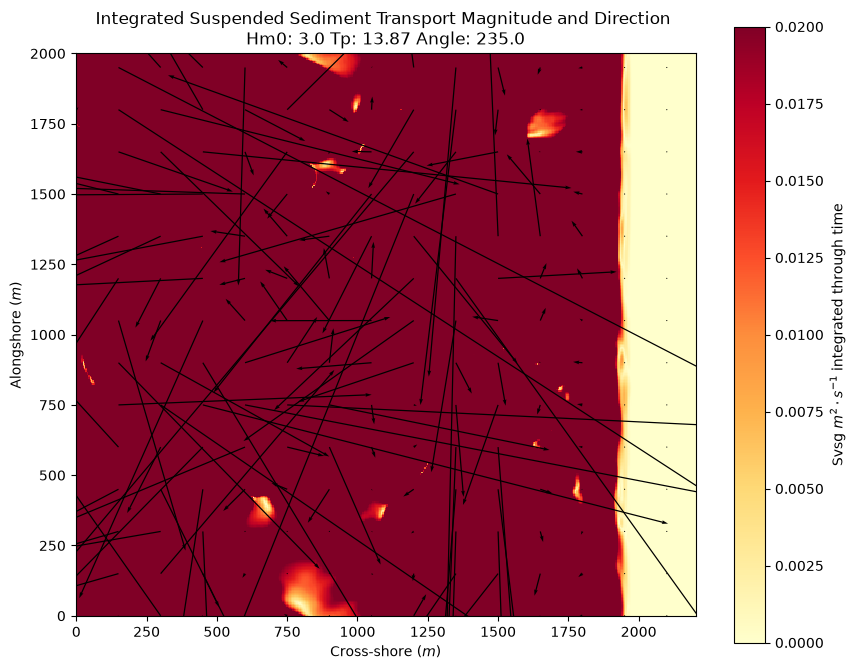

In [19]:
X = ds['globalx'].isel(ny=0).values  
Y = ds['globaly'].isel(nx=0).values  
X_mesh, Y_mesh = np.meshgrid(X, Y)

time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

ny, nx = len(Y), len(X)
u_sum = np.zeros((ny, nx))
v_sum = np.zeros((ny, nx))

for i in range(len(time)):
    u_step = ds['Susg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    v_step = ds['Svsg'].isel(globaltime=i).sum(dim='sediment_classes').values.squeeze() * dt[i]
    
    u_sum += u_step
    v_sum += v_step

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', vmin=0, vmax=.02, shading='auto')
cbar = fig.colorbar(im, label='Svsg $m^2 \cdot s^{-1}$ integrated through time')

skip = (slice(None, None, 30), slice(None, None, 30))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale=15, width=0.002)

ax.set_title(f"Integrated Suspended Sediment Transport Magnitude and Direction \nHm0: {wave_params['Hm0']} Tp: {wave_params['Tp']} Angle: {wave_params['mainang']}")
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
ax.set_aspect('equal')
plt.show()

In [ ]:
ds = xr.open_dataset("xbeach_cases/run_hm0_4.00_s0_0.0112_ang_305.00/xboutput.nc")

wave_params = {}
with open("xbeach_cases/run_hm0_4.00_s0_0.0112_ang_305.00/jonswap.txt", "r") as f:
    for line in f:
        if "=" in line:
            key, value = line.split("=")
            wave_params[key.strip()] = float(value.strip())